Zaimplementuj aplikację szacującą czas ukończenia półmaratonu dla zadanych danych

1. Umieść dane w Digital Ocean Spaces

1. Napisz notebook, który będzie Twoim pipelinem do trenowania modelu
    * czyta dane z Digital Ocean Spaces
    * czyści je
    * trenuje model (dobierz odpowiednie metryki [feature selection])
    * nowa wersja modelu jest zapisywana lokalnie i do Digital Ocean Spaces

1. Aplikacja
    * opakuj model w aplikację streamlit
    * wdróż (deploy) aplikację za pomocą Digital Ocean AppPlatform 
    * wejściem jest pole tekstowe, w którym użytkownik się przedstawia, mówi o tym
    jaka jest jego płeć, wiek i czas na 5km
    * jeśli użytkownik podał za mało danych, wyświetl informację o tym jakich danych brakuje
    * za pomocą LLM (OpenAI) wyłuskaj potrzebne dane, potrzebne dla Twojego modelu
    do określenia, do słownika (dictionary lub JSON)
    * tę część podepnij do Langfuse, aby zbierać metryki o skuteczności działania LLM'a



### Libraries

In [1]:
# !conda install -y conda-forge::pandera

In [1]:
import os
import boto3
from dotenv import load_dotenv
from botocore.exceptions import ClientError
from faker import Faker
import matplotlib.pyplot as plt
import pandera.pandas as pa
import seaborn as sns
import math
from pycaret.regression import setup, pull, compare_models, predict_model
from io import BytesIO
from datetime import datetime

load_dotenv()


# Utworzenie klienta - połączenia z DigitalOcean
s3 = boto3.client(
    "s3",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    endpoint_url=os.getenv("AWS_ENDPOINT_URL_S3"),
    
)


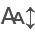

In [2]:
from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)

In [3]:
fake = Faker()

### CONSTANTS

In [4]:
BUCKET_NAME = "halfmarathon-test"
SOURCE_FILES = "sourceFile"
MOD_FILE = "Models"
CLEANED_FILES = "cleanedFile"
S3_SOURCE_FILES = "halfmarathons"
S3_MOD_FILE = "Models"
S3_CLEANED_FILES = "cleaned_HF_files"
TRAINING_SET = "halfmarathon_wroclaw_2023__final.csv"
PREPARED_DF = "prepared df"
READ_DF_FROM_SERVER = False

### Export + import csv from digitalocean

In [8]:
# Funcja do sprawdzenia czy bucked istnieje
def ensure_bucked_exist(bucked_name: str) -> None:
    try:
        s3.head_bucket(Bucket=bucked_name)
        print(f"Bucket '{bucked_name}' już istnieje")
    except ClientError as e:
        error_code = int(e.response["Error"]["Code"])
        if error_code == 404:
            # bucket nie istnieje - tworzyny go
            s3.create_bucket(Bucket=bucked_name)
            print(f"Bucket '{bucked_name}' został utworzony.")
        else:
            raise
        
ensure_bucked_exist(BUCKET_NAME)

Bucket 'halfmarathon-test' już istnieje


In [6]:
# Wyślijmy teraz wszystkie pliki z halfmarathon_final z danymi do Cloud Storage i zachowaj ścieżki do nich

#hfs_final = []

for root, dirs, files in os.walk(SOURCE_FILES):
    for file in files:
        file_path = os.path.join(root, file)
        s3_path = file_path.replace("\\","/").replace(SOURCE_FILES, S3_SOURCE_FILES)
        print(f"Wysyłam plik {os.path.join(root, file)} do {s3_path}") 
        s3.upload_file(
            Filename=file_path,
            Bucket=BUCKET_NAME,
            Key=s3_path
        )
    print (f'r:{root}, d:{dirs}, f:{files}')
        #hfs_final.append({"file": file, "s3_path": s3_path})

Wysyłam plik sourceFile\halfmarathon_wroclaw_2023__final.csv do halfmarathons/halfmarathon_wroclaw_2023__final.csv
Wysyłam plik sourceFile\halfmarathon_wroclaw_2024__final.csv do halfmarathons/halfmarathon_wroclaw_2024__final.csv
r:sourceFile, d:[], f:['halfmarathon_wroclaw_2023__final.csv', 'halfmarathon_wroclaw_2024__final.csv']


In [5]:
# Wylistujmy wszystkie pliki w Cloud Storage
response = s3.list_objects_v2(Bucket=BUCKET_NAME)

for obj in response["Contents"]:
    print(obj["Key"]) 

Models/best_5km_model.pkl
Models/best_5km_model_2023_2024.pkl
cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-07_00-15-56.csv
cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-07_19-54-14.csv
cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-07_20-07-35.csv
cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-07_20-13-53.csv
cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-08_23-31-22.csv
cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-09_09-09-14.csv
cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-09_15-43-43.csv
cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-09_19-57-52.csv
cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-11_23-26-24.csv
cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-13_23-40-59.csv
halfmarathons/halfmarathon_wroclaw_2023__final.csv
halfmarathons/halfmarathon_wroclaw_2024__final.csv


In [8]:
# Wylistujmy pliki po prefixie dla danego dnia
response = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=S3_SOURCE_FILES)
for obj in response["Contents"]:
    # print(obj["Key"])
    if TRAINING_SET in obj["Key"]:
        file_path = obj["Key"]
        print(f"File Founded {TRAINING_SET}")

File Founded halfmarathon_wroclaw_2023__final.csv


In [14]:
# Wczytaj plik do trenowania z DigitalOcean 

import pandas as pd
file = TRAINING_SET


# local read
if READ_DF_FROM_SERVER == False:
    df_raw = pd.read_csv('sourceFile/halfmarathon_wroclaw_2023__final.csv', sep=';')
else: # DigitalOcean read
    response = s3.get_object(
        Bucket=BUCKET_NAME,
        Key=file_path
    )
    print(f"Wczytano plik {file}")
    df_raw = pd.read_csv(response["Body"], sep=";")
if READ_DF_FROM_SERVER == False:
    df_raw2 = pd.read_csv('sourceFile/halfmarathon_wroclaw_2024__final.csv', sep=';')
else: # DigitalOcean read
    response = s3.get_object(
        Bucket=BUCKET_NAME,
        Key=file_path
    )
    print(f"Wczytano plik {file}")
    df_raw2 = pd.read_csv(response["Body"], sep=";")

df_raw["rok zawodów"] = int(2023)
df_raw2["rok zawodów"] = int(2024)

df = pd.concat([df_raw, df_raw2], axis=0, ignore_index=True)
df.head()

Miejsce  Numer startowy       Imię       Nazwisko   Miasto Kraj  \
0      1.0            1787     TOMASZ         GRYCKO      NaN  POL   
1      2.0               3  ARKADIUSZ  GARDZIELEWSKI  WROCŁAW  POL   
2      3.0            3832  KRZYSZTOF          HADAS   POZNAŃ  POL   
3      4.0             416     DAMIAN         DYDUCH    KĘPNO  POL   
4      5.0            8476      KAMIL      MAŃKOWSKI   MIRKÓW  POL   

                     Drużyna Płeć  Płeć Miejsce Kategoria wiekowa  ...  \
0     UKS BLIZA WŁADYSŁAWOWO    M           1.0               M30  ...   
1  ARKADIUSZGARDZIELEWSKI.PL    M           2.0               M30  ...   
2                        NaN    M           3.0               M20  ...   
3   AZS POLITECHNIKA OPOLSKA    M           4.0               M30  ...   
4            PARKRUN WROCŁAW    M           5.0               M20  ...   

   15 km Czas  15 km Miejsce Open 15 km Tempo  20 km Czas  20 km Miejsce Open  \
0    00:44:47                 1.0    3.106667    01:01:43                 1.0   
1    00:45:26                 2.0    3.143333    01:03:08                 2.0   
2    00:47:34                 3.0    3.236667    01:05:09                 3.0   
3    00:48:49                 5.0    3.330000    01:06:54                 4.0   
4    00:49:31                 7.0    3.386667    01:07:27                 5.0   

  20 km Tempo  Tempo Stabilność      Czas     Tempo  rok zawodów  
0    3.386667          0.031400  01:04:59  3.080509         2023  
1    3.540000          0.038000  01:06:23  3.146875         2023  
2    3.516667          0.024067  01:08:24  3.242475         2023  
3    3.616667          0.025467  01:10:16  3.330963         2023  
4    3.586667          0.023000  01:10:27  3.339654         2023  

[5 rows x 28 columns]

# CONVERT

### Covert - standarize time to [Sec]

In [15]:
# Snippet pomocniczy - zmiana czasu na sekundy

def convert_time_to_seconds(time):
    if pd.isnull(time) or time in ['DNS', 'DNF']:
        return None
    if  not isinstance(time, str):
        return time
    time = time.split(':')
    return int(time[0]) * 3600 + int(time[1]) * 60 + int(time[2])

### Convert - 'Czas', 'x km czas' to [Sec]

In [16]:
time_cols = ["Czas","5 km Czas", "10 km Czas", "15 km Czas", "20 km Czas"]
for col in time_cols:
    df[col] = df[col].apply(convert_time_to_seconds)

### Convert - place / Miejsca into INT64

In [17]:
int64_col = ["Miejsce","Płeć Miejsce", "Kategoria wiekowa Miejsce", "Rocznik", "5 km Miejsce Open", "10 km Miejsce Open", "15 km Miejsce Open", "20 km Miejsce Open"]
df[int64_col]=df[int64_col].astype("Int64")


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21957 entries, 0 to 21956
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Miejsce                    18450 non-null  Int64  
 1   Numer startowy             21957 non-null  int64  
 2   Imię                       21957 non-null  object 
 3   Nazwisko                   21957 non-null  object 
 4   Miasto                     17774 non-null  object 
 5   Kraj                       18450 non-null  object 
 6   Drużyna                    8402 non-null   object 
 7   Płeć                       21946 non-null  object 
 8   Płeć Miejsce               18450 non-null  Int64  
 9   Kategoria wiekowa          21926 non-null  object 
 10  Kategoria wiekowa Miejsce  18430 non-null  Int64  
 11  Rocznik                    21472 non-null  Int64  
 12  5 km Czas                  18411 non-null  float64
 13  5 km Miejsce Open          18411 non-null  Int

# Anonimization

### Swap - Name, Surname

In [19]:
df_Anonimized = df.copy()

In [17]:
def create_name(gender: str):
    if gender == 'M':
        return fake.first_name_male()
    elif gender == 'F':
        return fake.first_name_female()
    else:
        return 'Unknown Name'

In [21]:
df_Anonimized["Imię"] = df_Anonimized["Płeć"].apply(create_name)
df_Anonimized["Nazwisko"] = df_Anonimized["Nazwisko"].apply(lambda x: fake.last_name())

In [22]:
team_mapping = {team: f"TEAM_{i:03d}" for i, team in enumerate(df["Drużyna"].unique())}
# TEAM_001, TEAM_002, TEAM_003...
team_mapping_reverse = {v: k for k, v in team_mapping.items()}

### Swap - Team name

In [23]:
df_Anonimized["Drużyna"] = df_Anonimized["Drużyna"].map(team_mapping)

In [24]:
df_Anonimized.head()

Miejsce  Numer startowy      Imię   Nazwisko   Miasto Kraj   Drużyna Płeć  \
0        1            1787      Adam      Mills      NaN  POL  TEAM_000    M   
1        2               3    Justin  Fernandez  WROCŁAW  POL  TEAM_001    M   
2        3            3832       Lee   Williams   POZNAŃ  POL  TEAM_002    M   
3        4             416  Franklin   Figueroa    KĘPNO  POL  TEAM_003    M   
4        5            8476     Jared   Anderson   MIRKÓW  POL  TEAM_004    M   

   Płeć Miejsce Kategoria wiekowa  ...  15 km Czas  15 km Miejsce Open  \
0             1               M30  ...      2687.0                   1   
1             2               M30  ...      2726.0                   2   
2             3               M20  ...      2854.0                   3   
3             4               M30  ...      2929.0                   5   
4             5               M20  ...      2971.0                   7   

   15 km Tempo  20 km Czas  20 km Miejsce Open  20 km Tempo  Tempo Stabilność  \
0     3.106667      3703.0                   1     3.386667          0.031400   
1     3.143333      3788.0                   2     3.540000          0.038000   
2     3.236667      3909.0                   3     3.516667          0.024067   
3     3.330000      4014.0                   4     3.616667          0.025467   
4     3.386667      4047.0                   5     3.586667          0.023000   

     Czas     Tempo  rok zawodów  
0  3899.0  3.080509         2023  
1  3983.0  3.146875         2023  
2  4104.0  3.242475         2023  
3  4216.0  3.330963         2023  
4  4227.0  3.339654         2023  

[5 rows x 28 columns]

In [25]:
df = df_Anonimized.copy()

#### Swap back team name mapping

In [26]:
# df_Anonimized["Drużyna"] = df_Anonimized["Drużyna"].map(team_mapping_reverse)

In [27]:
df = df.dropna(subset=['Płeć'])
df["Płeć"].unique()

array(['M', 'K'], dtype=object)

In [28]:
df = df.dropna(subset=['5 km Czas', '10 km Czas', '15 km Czas', '20 km Czas'], how='all')
print(df.isna().sum())


Miejsce                        0
Numer startowy                 0
Imię                           0
Nazwisko                       0
Miasto                       673
Kraj                           0
Drużyna                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa             18
Kategoria wiekowa Miejsce     18
Rocznik                      484
5 km Czas                     36
5 km Miejsce Open             36
5 km Tempo                    36
10 km Czas                    20
10 km Miejsce Open            20
10 km Tempo                   52
15 km Czas                    19
15 km Miejsce Open            19
15 km Tempo                   34
20 km Czas                     8
20 km Miejsce Open             8
20 km Tempo                   25
Tempo Stabilność              70
Czas                           0
Tempo                          0
rok zawodów                    0
dtype: int64


## FILLING

### Filling NA

In [29]:
fill_mapping = ['Miasto', 'Drużyna']
df[fill_mapping] = df[fill_mapping].fillna('No Data')
print(df.isna().sum())


Miejsce                        0
Numer startowy                 0
Imię                           0
Nazwisko                       0
Miasto                         0
Kraj                           0
Drużyna                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa             18
Kategoria wiekowa Miejsce     18
Rocznik                      484
5 km Czas                     36
5 km Miejsce Open             36
5 km Tempo                    36
10 km Czas                    20
10 km Miejsce Open            20
10 km Tempo                   52
15 km Czas                    19
15 km Miejsce Open            19
15 km Tempo                   34
20 km Czas                     8
20 km Miejsce Open             8
20 km Tempo                   25
Tempo Stabilność              70
Czas                           0
Tempo                          0
rok zawodów                    0
dtype: int64


### Filling 'Rocznik' - test / preparation

In [30]:
R = 'Rocznik'
V = '5 km Czas'
searched = 1260
delta = 3
df_kalk = df[(df[V] >= searched - delta) & (df[V] <= searched + delta) & (df[R] > 0)]
print(f'zaokrąglenie: {round(df_kalk[R].mean())}, ilość: {df_kalk[R].count()}')
display(df_kalk)

zaokrąglenie: 1984, ilość: 41


Miejsce  Numer startowy          Imię    Nazwisko            Miasto  \
174        175             163         Brian    Robinson           CHIRPAN   
229        230            5726       Michael    Santiago             LUBAŃ   
303        304            4347         David      Stuart           SPŁAWIE   
321        322            7223         Bobby   Henderson          WILCZYCE   
327        328            4064         Brent      Powell            POZNAŃ   
376        377             406          Ryan    Galloway            UTRATA   
381        382            4971       Charles      Pruitt           WROCŁAW   
387        388            7202   Christopher      Miller          ŻELAZKÓW   
394        395            5904          Mike        Diaz              WIRY   
411        412            8975        Joseph    Hamilton              ŁÓDŹ   
430        431            3468         Derek    Stephens           WROCŁAW   
441        442            1062         David     Jackson          SZCZECIN   
445        446            2050         Scott     Osborne           WROCŁAW   
498        499            9544       Vincent      Garcia           WROCŁAW   
738        739            1867         Jacob      Thomas           WROCŁAW   
787        788            4846        Walter       Jones            LIGOTA   
9061       112             176         James        Reid            POZNAŃ   
9119       170            1092       Charles   Hernandez  KĘDZIERZYN-KOŹLE   
9145       196             301        Steven        Chen           WROCŁAW   
9147       198             116       Stephen     Daniels         BOGATYNIA   
9154       205             322         David        Ward             BRZEG   
9183       234            1733      Benjamin    Hamilton          SZCZECIN   
9202       253             903         David    Shepherd           CHORZÓW   
9205       256             604          Eric    Robinson           MROCZEŃ   
9206       257            1244         Dylan      Thomas           WROCŁAW   
9210       261            1612        Justin       Green        DOMASZCZYN   
9230       281             448         Bobby       Reese          GROBLICE   
9269       320            1919         Craig  Villarreal           WROCŁAW   
9294       345             194          Adam      Thomas         MARCISZÓW   
9320       371             320  Unknown Name      Rivera   PIEKARY ŚLĄSKIE   
9327       378            3532        Calvin   Henderson           WROCŁAW   
9331       382              64          Paul     Collins   MASŁÓW PIERWSZY   
9366       417             573          Sean      Garner       ALEKSANDROW   
9378       429             261          John   Gutierrez   TARNOWSKIE GÓRY   
9385       436             313        Joshua      Jordan            POZNAŃ   
9447       498             510        Elijah         Lin         BYDGOSZCZ   
9458       509             349       Matthew      Wilson            OPATÓW   
9591       642             352       Anthony      Zavala          ŚWIDNICA   
9818       869             928        Thomas        Wood           WROCŁAW   
9928       979            3542       William     Fuentes          ŚWIDNICA   
16972     8023             314         Harry      Graham            DĘBICA   

      Kraj    Drużyna Płeć  Płeć Miejsce Kategoria wiekowa  ...  15 km Czas  \
174    BUL   TEAM_099    M           166               M20  ...      3679.0   
229    POL   TEAM_126    M           219               M30  ...      3710.0   
303    POL   TEAM_002    M           293               M50  ...      3759.0   
321    POL   TEAM_002    M           309               M40  ...      3781.0   
327    POL   TEAM_002    M           314               M30  ...      3780.0   
376    POL   TEAM_002    M           362               M40  ...      3789.0   
381    POL   TEAM_002    M           367               M40  ...      3829.0   
387    POL   TEAM_198    M           372               M40  ...      3814.0   
394    POL   TEAM_0

### Filling 'Rocznik' - Function

In [19]:
def fillRocznik(dataFrame: pd.DataFrame, searched: int, delta: int = 5, V: str = '5 km Czas') -> int:
    R = 'Rocznik'
    
    df_kalk = dataFrame[(df[V] >= searched - delta) & (df[V] <= searched + delta) & (df[R] > 0)]
    print(f'zaokrąglenie: {round(df_kalk[R].mean())}, ilość: {df_kalk[R].count()}')
    return round(df_kalk[R].mean())

fillRocznik(df, 1260)

zaokrąglenie: 1984, ilość: 81


1984

In [32]:
df.loc[df['Rocznik'] == 0, 'Rocznik'] = df.loc[df['Rocznik'] == 0, '5 km Czas'].apply(lambda czas: fillRocznik(df, czas))

zaokrąglenie: 1983, ilość: 79
zaokrąglenie: 1986, ilość: 62
zaokrąglenie: 1984, ilość: 107
zaokrąglenie: 1984, ilość: 242
zaokrąglenie: 1985, ilość: 267
zaokrąglenie: 1985, ilość: 322
zaokrąglenie: 1984, ilość: 269
zaokrąglenie: 1987, ilość: 30
zaokrąglenie: 1980, ilość: 6
zaokrąglenie: 1985, ilość: 296
zaokrąglenie: 1984, ilość: 415
zaokrąglenie: 1984, ilość: 323
zaokrąglenie: 1984, ilość: 146
zaokrąglenie: 1984, ilość: 150
zaokrąglenie: 1985, ilość: 131
zaokrąglenie: 1982, ilość: 146
zaokrąglenie: 1984, ilość: 83
zaokrąglenie: 1983, ilość: 3


In [3]:
df[df['Kategoria wiekowa'].isna()]

NameError: name 'df' is not defined

### Filling 'Kategoria wiekowa' - function autofill according 'Rocznik' data

In [20]:

# df.loc[df['Kategoria wiekowa'].isna(), 'Kategoria wiekowa'] = df.loc[df['Kategoria wiekowa'].isna(), 'Rocznik']
# actYear = 2023
def fill_KategoriaWiekowa(row, actYear: int, all=False):
    if all or pd.isna(row['Kategoria wiekowa']) and row['Rocznik'] > 0:
        # row['Kategoria wiekowa'] = row['Płeć'] & str(round(actYear - row['Rocznik'], 2))
        r = row['Płeć'] + str((math.ceil((actYear - row['Rocznik'])/10)*10))
        # print(r)
        return r
    return row['Kategoria wiekowa']
df2 = df.copy()
df['Kategoria wiekowa'] = df.apply(fill_KategoriaWiekowa, axis=1, args=(2023,))

In [35]:
df[df["Rocznik"].isna()].head()
# df.isna().sum()

Miejsce  Numer startowy    Imię    Nazwisko   Miasto Kraj   Drużyna Płeć  \
79        80            1849   Keith    Williams  No Data  POL  TEAM_045    M   
173      174            9542    Chad        Wolf  No Data  POL  TEAM_002    M   
538      539            6926   Jason       Clark  No Data  POL  TEAM_269    M   
543      544            5082  Robert  Mclaughlin  No Data  POL  TEAM_002    M   
626      627            4414   James      Barnes  No Data  POL  TEAM_304    M   

     Płeć Miejsce Kategoria wiekowa  ...  15 km Czas  15 km Miejsce Open  \
79             77               M40  ...      3398.0                  61   
173           165               M40  ...      3640.0                 196   
538           505               M30  ...      4007.0                 640   
543           510               M30  ...      3874.0                 455   
626           586               M30  ...      4102.0                 802   

     15 km Tempo  20 km Czas  20 km Miejsce Open  20 km Tempo  \
79      3.900000      4690.0                  75     4.306667   
173     4.123333      4961.0                 175     4.403333   
538     4.420000      5417.0                 550     4.700000   
543     4.450000      5384.0                 519     5.033333   
626     4.560000      5518.0                 655     4.720000   

     Tempo Stabilność    Czas     Tempo  rok zawodów  
79           0.039200  4931.0  3.895868         2023  
173          0.024733  5205.0  4.112349         2023  
538          0.010733  5670.0  4.479735         2023  
543          0.054000  5679.0  4.486845         2023  
626          0.005733  5757.0  4.548471         2023  

[5 rows x 28 columns]

### Filling 'Rocznik' - metoda ffill()

In [36]:
# zapisz indeksy przed wypełnieniem
idx_nan = df[df['Rocznik'].isna()].index

# po wypełnieniu sprawdź te wiersze
df.loc[idx_nan, ['Kategoria wiekowa', 'Rocznik']]

Kategoria wiekowa  Rocznik
79                  M40     <NA>
173                 M40     <NA>
538                 M30     <NA>
543                 M30     <NA>
626                 M30     <NA>
...                 ...      ...
19216               M60     <NA>
19233               M20     <NA>
19234               K30     <NA>
19240               K20     <NA>
19249               M40     <NA>

[484 rows x 2 columns]

In [37]:
df['Rocznik'] = df.groupby('Kategoria wiekowa')['Rocznik'].ffill()

In [38]:
# po wypełnieniu sprawdź te wiersze
df_Test = df.loc[idx_nan, ['Kategoria wiekowa', 'Rocznik']]

In [39]:
df_Test['Szac_kategoria'] = df_Test.apply(fill_KategoriaWiekowa, axis=1, args=(2023,))
df_Test

Kategoria wiekowa  Rocznik Szac_kategoria
79                  M40     1976            M40
173                 M40     1978            M40
538                 M30     1993            M30
543                 M30     1993            M30
626                 M30     1991            M30
...                 ...      ...            ...
19216               M60     1962            M60
19233               M20     1998            M20
19234               K30     1993            K30
19240               K20     2004            K20
19249               M40     1976            M40

[484 rows x 3 columns]

## Checking 'Kategoria wiekowa'

In [40]:
display(df_Test.groupby('Kategoria wiekowa')['Rocznik'].agg(['min', 'max', 'mean']))
display(df.groupby('Kategoria wiekowa')['Rocznik'].agg(['min', 'max', 'mean']))


min   max         mean
Kategoria wiekowa                         
K20                1994  2005  1998.592593
K30                1984  1994       1989.0
K40                1974  1984  1979.784314
K50                1970  1973       1971.5
M20                1994  2005  1998.233766
M30                1984  1994  1989.162162
M40                1974  1984  1979.129032
M50                1964  1974       1971.6
M60                1956  1962  1958.833333

min   max         mean
Kategoria wiekowa                         
K20                1994  2006   1998.17835
K30                1984  1994  1989.021613
K40                1974  1984  1979.587595
K50                1964  1974  1970.810748
K60                1954  1964  1960.378049
K70                1948  1954  1951.818182
M20                1994  2006  1998.230513
M30                1984  1994  1988.851165
M40                1974  1987   1979.43619
M50                1964  1982  1970.521798
M60                1954  1964  1959.698077
M70                1944  1954    1950.7625
M80                1934  1944  1940.333333

### Delete rows with NA for 'Kategoria wiekowa' and 'Rocznik'

In [41]:
df = df.dropna(subset=['Kategoria wiekowa'], how='all')

In [42]:
df['Sugerowana kategoria wiekowa'] = df.apply(fill_KategoriaWiekowa, axis=1, args=(2023,))

In [43]:
df[['Sugerowana kategoria wiekowa', 'Kategoria wiekowa']]

Sugerowana kategoria wiekowa Kategoria wiekowa
0                              M30               M30
1                              M30               M30
2                              M20               M20
3                              M30               M30
4                              M20               M20
...                            ...               ...
19245                          K70               K70
19246                          K40               K40
19247                          K60               K60
19248                          K40               K40
19249                          M40               M40

[18447 rows x 2 columns]

In [44]:
df[df['Sugerowana kategoria wiekowa'] != df['Kategoria wiekowa']]

Empty DataFrame
Columns: [Miejsce, Numer startowy, Imię, Nazwisko, Miasto, Kraj, Drużyna, Płeć, Płeć Miejsce, Kategoria wiekowa, Kategoria wiekowa Miejsce, Rocznik, 5 km Czas, 5 km Miejsce Open, 5 km Tempo, 10 km Czas, 10 km Miejsce Open, 10 km Tempo, 15 km Czas, 15 km Miejsce Open, 15 km Tempo, 20 km Czas, 20 km Miejsce Open, 20 km Tempo, Tempo Stabilność, Czas, Tempo, rok zawodów, Sugerowana kategoria wiekowa]
Index: []

[0 rows x 29 columns]

In [45]:
df_Test[df_Test['Szac_kategoria'] != df_Test['Kategoria wiekowa']]

Empty DataFrame
Columns: [Kategoria wiekowa, Rocznik, Szac_kategoria]
Index: []

In [46]:
print('Sprawdzenie czy Rocznik pasuje do kategorii wiekowejc')
df.groupby('Kategoria wiekowa')['Rocznik'].agg(['min', 'max', 'mean'])

Sprawdzenie czy Rocznik pasuje do kategorii wiekowejc


min   max         mean
Kategoria wiekowa                         
K20                1994  2006   1998.17835
K30                1984  1994  1989.021613
K40                1974  1984  1979.587595
K50                1964  1974  1970.810748
K60                1954  1964  1960.378049
K70                1948  1954  1951.818182
M20                1994  2006  1998.230513
M30                1984  1994  1988.851165
M40                1974  1987   1979.43619
M50                1964  1982  1970.521798
M60                1954  1964  1959.698077
M70                1944  1954    1950.7625
M80                1934  1944  1940.333333

In [47]:
df[df["5 km Czas"].isna()].head()

Miejsce  Numer startowy      Imię   Nazwisko     Miasto Kraj   Drużyna  \
159      160            6352     Shane       Lara  ZGORZELEC  POL  TEAM_090   
165      166            1128     David  Cervantes     LESZNO  POL  TEAM_094   
224      225            2402     Brian   Stephens    LEGNICA  POL  TEAM_123   
248      249            2879    Daniel     Zavala    WROCŁAW  POL  TEAM_135   
270      271            8424  Geoffrey    Maxwell    WROCŁAW  POL  TEAM_002   

    Płeć  Płeć Miejsce Kategoria wiekowa  ...  15 km Miejsce Open  \
159    M           153               M20  ...                 139   
165    M           157               M30  ...                 187   
224    M           214               M40  ...                 266   
248    M           238               M50  ...                 268   
270    M           260               M40  ...                 327   

     15 km Tempo  20 km Czas  20 km Miejsce Open  20 km Tempo  \
159     4.033333      4913.0                 157     4.540000   
165     4.120000      4947.0                 170     4.413333   
224     4.166667      5050.0                 232     4.443333   
248     4.206667      5074.0                 252     4.520000   
270     4.270000      5109.0                 275     4.486667   

     Tempo Stabilność    Czas     Tempo  rok zawodów  \
159               NaN  5160.0  4.076795         2023   
165               NaN  5186.0  4.097337         2023   
224               NaN  5289.0  4.178715         2023   
248               NaN  5316.0  4.200047         2023   
270               NaN  5350.0  4.226910         2023   

     Sugerowana kategoria wiekowa  
159                           M20  
165                           M30  
224                           M40  
248                           M50  
270                           M40  

[5 rows x 29 columns]

In [48]:
df[df["Rocznik"] == 0 & df["Kategoria wiekowa"].isna()].head()  

Empty DataFrame
Columns: [Miejsce, Numer startowy, Imię, Nazwisko, Miasto, Kraj, Drużyna, Płeć, Płeć Miejsce, Kategoria wiekowa, Kategoria wiekowa Miejsce, Rocznik, 5 km Czas, 5 km Miejsce Open, 5 km Tempo, 10 km Czas, 10 km Miejsce Open, 10 km Tempo, 15 km Czas, 15 km Miejsce Open, 15 km Tempo, 20 km Czas, 20 km Miejsce Open, 20 km Tempo, Tempo Stabilność, Czas, Tempo, rok zawodów, Sugerowana kategoria wiekowa]
Index: []

[0 rows x 29 columns]

## Zapisywanie przygotowanego DF do Digital Ocean

In [49]:
data = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
csv_name = f"Cleaned-halfmarathon-data_{data}.csv"

# df = pd.read_csv('cleanedFile\Cleaned-halfmarathon-data_2026-07-07_00-08-37.csv', sep=";")
# Zapis lokalny
os.makedirs(CLEANED_FILES, exist_ok=True)
local_file_path = os.path.join(CLEANED_FILES, csv_name)
df.to_csv(local_file_path, index=False, encoding='utf-8', sep=';')
print(f"Zapisano lokalnie: {local_file_path}")

# Zapis Digital Ocean
csv_buffer = BytesIO()
df.to_csv(csv_buffer, index=False, encoding='utf-8')
s3_path = local_file_path.replace("\\","/").replace(CLEANED_FILES, S3_CLEANED_FILES)
print(f"Wysyłam plik {local_file_path} do {s3_path}") 
s3.upload_file(
    Filename=local_file_path,
    Bucket=BUCKET_NAME,
    Key=s3_path
)


Zapisano lokalnie: cleanedFile\Cleaned-halfmarathon-data_2026-07-13_23-40-59.csv
Wysyłam plik cleanedFile\Cleaned-halfmarathon-data_2026-07-13_23-40-59.csv do cleaned_HF_files/Cleaned-halfmarathon-data_2026-07-13_23-40-59.csv


## Odczytanie przygotowanego DF z Digital Ocean

In [63]:
fileName = 'Cleaned-halfmarathon-data_2026-07-13_23-40-59.csv'
# Wylistujmy pliki po prefixie dla danego dnia
response = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=S3_CLEANED_FILES)
for obj in response["Contents"]:
    # print(obj["Key"])
    if fileName in obj["Key"]:
        file_path = obj["Key"]
        print(f"File Founded {fileName}")
        

response = s3.get_object(
    Bucket=BUCKET_NAME,
    Key=file_path
)
print(f"Wczytano plik {fileName}")
df_cleaned = pd.read_csv(response["Body"], sep=";")

File Founded Cleaned-halfmarathon-data_2026-07-13_23-40-59.csv
Wczytano plik Cleaned-halfmarathon-data_2026-07-13_23-40-59.csv


In [64]:
df = df_cleaned.copy()
df.head()

Miejsce  Numer startowy      Imię   Nazwisko   Miasto Kraj   Drużyna Płeć  \
0        1            1787      Adam      Mills  No Data  POL  TEAM_000    M   
1        2               3    Justin  Fernandez  WROCŁAW  POL  TEAM_001    M   
2        3            3832       Lee   Williams   POZNAŃ  POL  TEAM_002    M   
3        4             416  Franklin   Figueroa    KĘPNO  POL  TEAM_003    M   
4        5            8476     Jared   Anderson   MIRKÓW  POL  TEAM_004    M   

   Płeć Miejsce Kategoria wiekowa  ...  15 km Miejsce Open  15 km Tempo  \
0             1               M30  ...                 1.0     3.106667   
1             2               M30  ...                 2.0     3.143333   
2             3               M20  ...                 3.0     3.236667   
3             4               M30  ...                 5.0     3.330000   
4             5               M20  ...                 7.0     3.386667   

   20 km Czas  20 km Miejsce Open  20 km Tempo  Tempo Stabilność    Czas  \
0      3703.0                 1.0     3.386667          0.031400  3899.0   
1      3788.0                 2.0     3.540000          0.038000  3983.0   
2      3909.0                 3.0     3.516667          0.024067  4104.0   
3      4014.0                 4.0     3.616667          0.025467  4216.0   
4      4047.0                 5.0     3.586667          0.023000  4227.0   

      Tempo  rok zawodów  Sugerowana kategoria wiekowa  
0  3.080509         2023                           M30  
1  3.146875         2023                           M30  
2  3.242475         2023                           M20  
3  3.330963         2023                           M30  
4  3.339654         2023                           M20  

[5 rows x 29 columns]

## Tests - linear dependences

In [50]:
linear_df = df[['5 km Czas', '15 km Czas']].copy()

<Axes: xlabel='5 km Czas', ylabel='15 km Czas'>

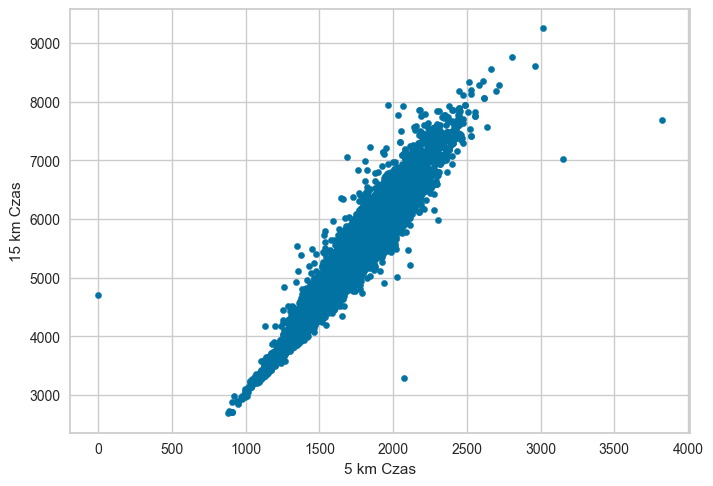

In [51]:
linear_df.plot.scatter(x='5 km Czas', y='15 km Czas')

In [52]:
linear_2_df = df[['5 km Czas', '10 km Czas']].dropna(subset='10 km Czas').sort_values('10 km Czas').interpolate().round()

In [53]:
linear_2_df[df['5 km Czas'].isna()]

5 km Czas  10 km Czas
159       1170.0      2341.0
345       1174.0      2376.0
165       1197.0      2387.0
276       1217.0      2452.0
248       1230.0      2456.0
224       1232.0      2467.0
270       1260.0      2482.0
461       1267.0      2499.0
421       1262.0      2509.0
684       1264.0      2510.0
348       1273.0      2532.0
503       1287.0      2553.0
458       1298.0      2587.0
10054     1390.0      2771.0
10227     1458.0      2875.0
11462     1464.0      2898.0
1841      1489.0      2919.0
1787      1462.0      2924.0
1366      1510.0      2957.0
2181      1548.0      3037.0
11247     1508.0      3043.0
2886      1553.0      3065.0
3928      1594.0      3176.0
3937      1548.0      3178.0
3986      1616.0      3243.0
5153      1658.0      3299.0
13108     1684.0      3326.0
13784     1711.0      3392.0
15167     1734.0      3450.0
7662      1820.0      3582.0
15867     1863.0      3749.0
17498     1992.0      3944.0

<Axes: xlabel='5 km Czas', ylabel='10 km Czas'>

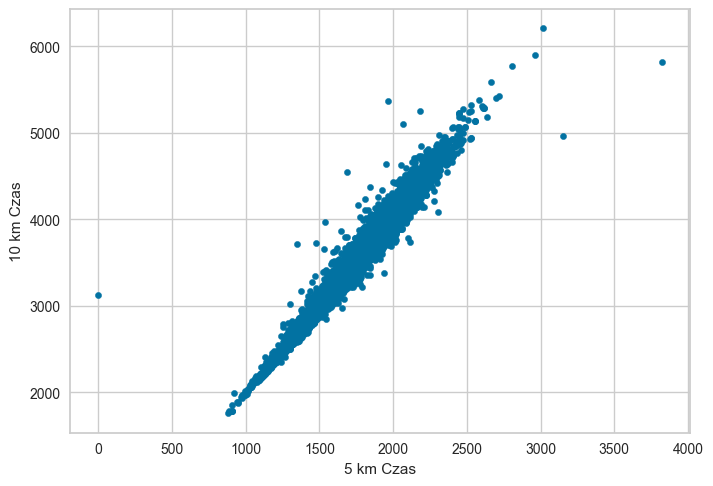

In [54]:
linear_2_df.plot.scatter(x='5 km Czas', y='10 km Czas')

In [55]:
linear_3_df = df[['5 km Czas', 'Czas']].copy()

<Axes: xlabel='5 km Czas', ylabel='Czas'>

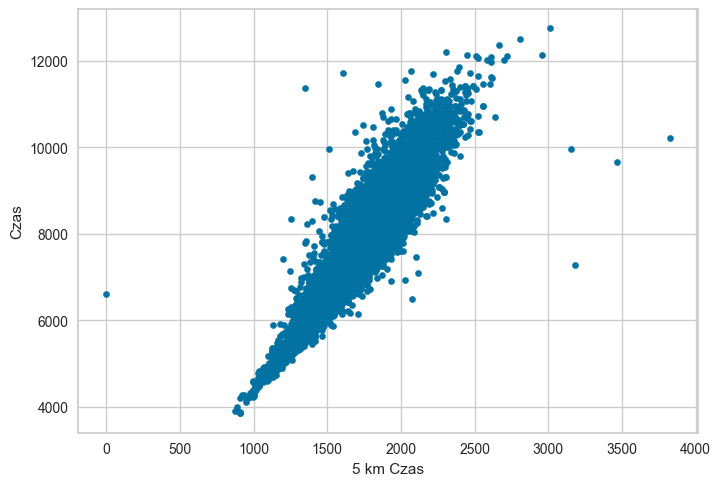

In [56]:
linear_3_df.plot.scatter(x='5 km Czas', y='Czas')

In [57]:
linear_4_df = df[['5 km Czas', 'Czas']].dropna(subset='Czas').sort_values('Czas').interpolate().round()

<Axes: xlabel='5 km Czas', ylabel='Czas'>

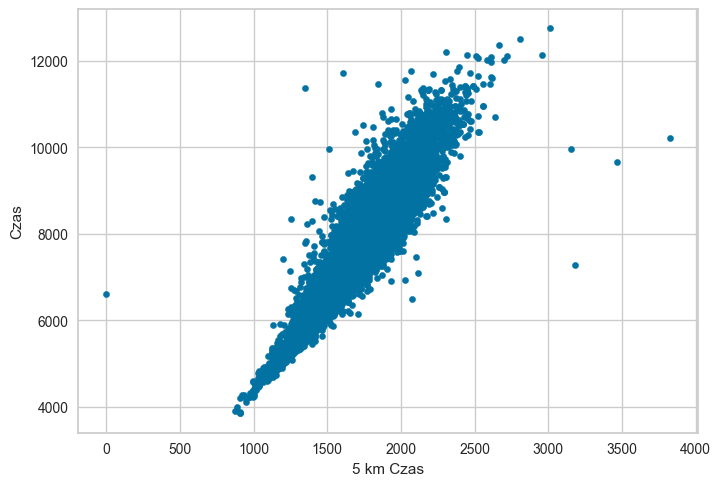

In [58]:
linear_4_df.plot.scatter(x='5 km Czas', y='Czas')

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18447 entries, 0 to 19249
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Miejsce                       18447 non-null  Int64  
 1   Numer startowy                18447 non-null  int64  
 2   Imię                          18447 non-null  object 
 3   Nazwisko                      18447 non-null  object 
 4   Miasto                        18447 non-null  object 
 5   Kraj                          18447 non-null  object 
 6   Drużyna                       18447 non-null  object 
 7   Płeć                          18447 non-null  object 
 8   Płeć Miejsce                  18447 non-null  Int64  
 9   Kategoria wiekowa             18447 non-null  object 
 10  Kategoria wiekowa Miejsce     18429 non-null  Int64  
 11  Rocznik                       18447 non-null  Int64  
 12  5 km Czas                     18411 non-null  float64
 13  5 km M

## Schema - preparation

In [22]:
schema = pa.DataFrameSchema(
    {
        "Miejsce":                    pa.Column(pd.Int64Dtype(), nullable=True),
        "Numer startowy":             pa.Column(int, nullable=False),
        "Imię":                       pa.Column(str, nullable=False),
        "Nazwisko":                   pa.Column(str, nullable=False),
        "Miasto":                     pa.Column(str, nullable=True),
        "Kraj":                       pa.Column(str, nullable=True),
        "Drużyna":                    pa.Column(str, nullable=True),
        "Płeć":                       pa.Column(str, pa.Check.isin(['M','K']), nullable=True),
        "Płeć Miejsce":               pa.Column(pd.Int64Dtype(), nullable=True),
        "Kategoria wiekowa":          pa.Column(str, nullable=True),
        "Kategoria wiekowa Miejsce":  pa.Column(pd.Int64Dtype(), pa.Check.greater_than_or_equal_to(0), nullable=True),
        "Rocznik":                    pa.Column(pd.Int64Dtype(), pa.Check.in_range(0, 2026), nullable=True),
        "5 km Czas":                  pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=True),
        "5 km Miejsce Open":          pa.Column(pd.Int64Dtype(), pa.Check.greater_than_or_equal_to(0), nullable=True),
        "5 km Tempo":                 pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=True),
        "10 km Czas":                 pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=True),
        "10 km Miejsce Open":         pa.Column(pd.Int64Dtype(), pa.Check.greater_than_or_equal_to(0), nullable=True),
        "10 km Tempo":                pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=True),
        "15 km Czas":                 pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=True),
        "15 km Miejsce Open":         pa.Column(pd.Int64Dtype(), pa.Check.greater_than_or_equal_to(0), nullable=True),
        "15 km Tempo":                pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=True),
        "20 km Czas":                 pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=True),
        "20 km Miejsce Open":         pa.Column(pd.Int64Dtype(), pa.Check.greater_than_or_equal_to(0), nullable=True),
        "20 km Tempo":                pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=True),
        "Tempo Stabilność":           pa.Column(float, nullable=True),
        "Czas":                       pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=True),
        "Tempo":                      pa.Column(float, pa.Check.greater_than_or_equal_to(0), nullable=True),
    }
)

## Schema validation

In [61]:
schema.validate(df)

Miejsce  Numer startowy          Imię   Nazwisko            Miasto  \
0            1            1787          Adam      Mills           No Data   
1            2               3        Justin  Fernandez           WROCŁAW   
2            3            3832           Lee   Williams            POZNAŃ   
3            4             416      Franklin   Figueroa             KĘPNO   
4            5            8476         Jared   Anderson            MIRKÓW   
...        ...             ...           ...        ...               ...   
19245    10298             898  Unknown Name  Castaneda            POZNAŃ   
19246    10299           10456  Unknown Name      Burns           No Data   
19247    10300           11311  Unknown Name      Davis           WROCŁAW   
19248    10301            8404  Unknown Name   Robinson  KATY WROCLAWSKIE   
19249    10302           11155         Brian     Zamora           No Data   

      Kraj    Drużyna Płeć  Płeć Miejsce Kategoria wiekowa  ...  \
0      POL   TEAM_000    M             1               M30  ...   
1      POL   TEAM_001    M             2               M30  ...   
2      POL   TEAM_002    M             3               M20  ...   
3      POL   TEAM_003    M             4               M30  ...   
4      POL   TEAM_004    M             5               M20  ...   
...    ...        ...  ...           ...               ...  ...   
19245  POL  TEAM_1208    K          3059               K70  ...   
19246  POL   TEAM_002    K          3060               K40  ...   
19247  POL   TEAM_004    K          3061               K60  ...   
19248  POL  TEAM_2090    K          3062               K40  ...   
19249  POL   TEAM_002    M          7240               M40  ...   

       15 km Miejsce Open  15 km Tempo  20 km Czas  20 km Miejsce Open  \
0                       1     3.106667      3703.0                   1   
1                       2     3.143333      3788.0                   2   
2                       3     3.236667      3909.0                   3   
3                       5     3.330000      4014.0                   4   
4                       7     3.386667      4047.0                   5   
...                   ...          ...         ...                 ...   
19245                <NA>          NaN         NaN                <NA>   
19246               10301     9.580000     11419.0               10303   
19247               10303     9.010000     11494.0               10304   
19248               10304     9.980000     11845.0               10305   
19249               10305    10.136667     12082.0               10306   

       20 km Tempo  Tempo Stabilność     Czas      Tempo  rok zawodów  \
0         3.386667          0.031400   3899.0   3.080509         2023   
1         3.540000          0.038000   3983.0   3.146875         2023   
2         3.516667          0.024067   4104.0   3.242475         2023   
3         3.616667          0.025467   4216.0   3.330963         2023   
4         3.586667          0.023000   4227.0   3.339654         2023   
...            ...               ...      ...        ...          ...   
19245          NaN               NaN  11987.0   9.470649         2024   
19246    10.970000          0.162733  12068.0   9.534645         2024   
19247     9.640000         -0.029333  12138.0   9.589950         2024   
19248    10.273333          0.057000  12512.0   9.885439         2024   
19249     9.443333         -0.046400  12754.0  10.076637         2024   

       Sugerowana kategoria wiekowa  
0                               M30  
1                               M30  
2                               M20  
3                               M30  
4                               M20  
...                             ...  
19245                           K70  
19246                           K40  
19247                           K60  
19248                           K40  
19249                           M40  

[18447 rows x 29 columns]

## Plots

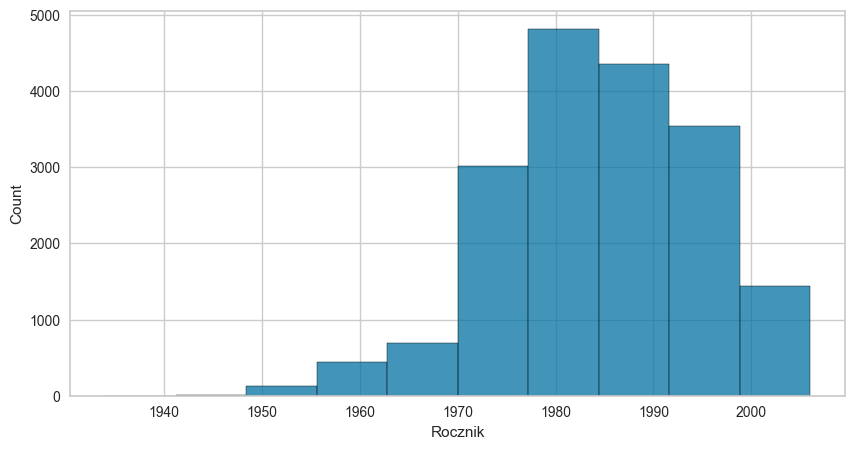

In [62]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Rocznik"], bins=10);

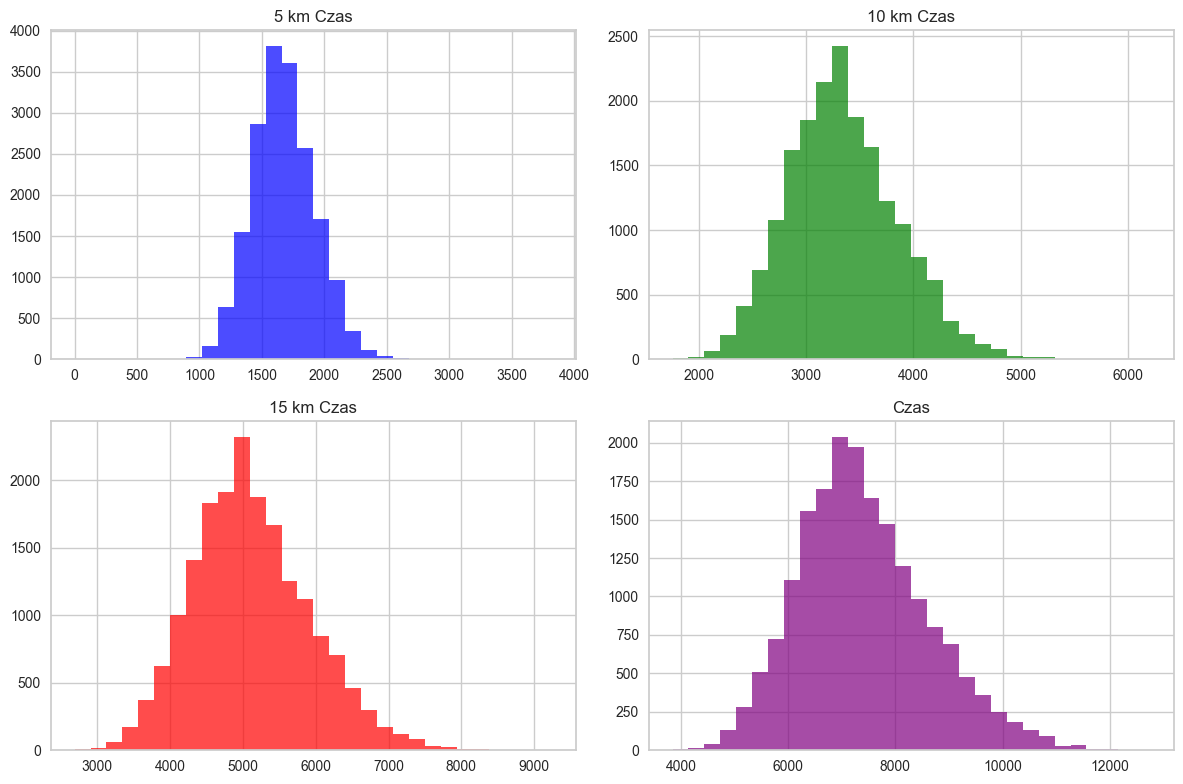

In [63]:
ig, axes = plt.subplots(2, 2, figsize=(12, 8))

y = df['5 km Czas']

axes[0, 0].hist(y, bins=30, color='blue', alpha=0.7)
axes[0, 0].set_title("5 km Czas")

y = df['10 km Czas']
axes[0, 1].hist(y, bins=30, color='green', alpha=0.7)
axes[0, 1].set_title("10 km Czas")

y = df['15 km Czas']
axes[1, 0].hist(y, bins=30, color='red', alpha=0.7)
axes[1, 0].set_title("15 km Czas")

y = df['Czas']
axes[1, 1].hist(y, bins=30, color='purple', alpha=0.7)
axes[1, 1].set_title("Czas")

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Halfmarathon Czas')

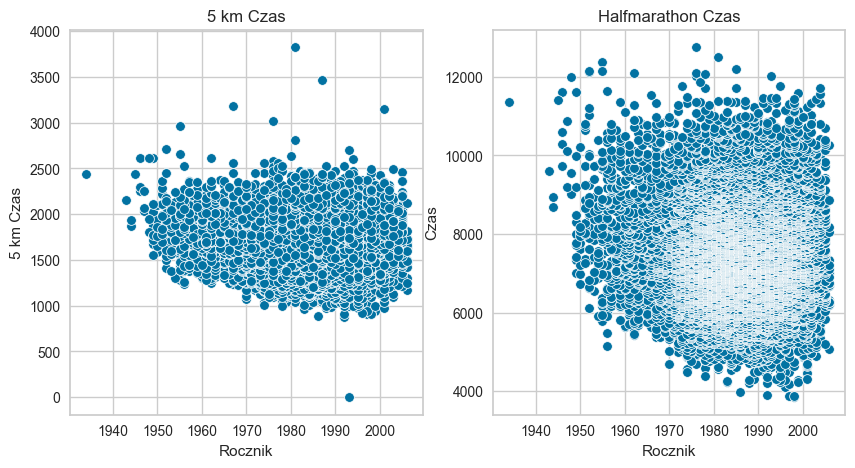

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(data=df, x="Rocznik", y="5 km Czas", ax=axes[0])
axes[0].set_title("5 km Czas")

sns.scatterplot(data=df, x="Rocznik", y="Czas", ax=axes[1])
axes[1].set_title("Halfmarathon Czas")


In [65]:
df = df.dropna(subset='Rocznik', how='any')
df['Rocznik'].isna().sum()

0

In [87]:
Col = "5 km Czas"
Q1 = df[Col].quantile(0.25)
Q3 = df[Col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Distance_5km_no_outliers_df = df[~((df[Col] < lower_bound) | (df[Col] > upper_bound))]

Text(0.5, 1.0, 'without outliers')

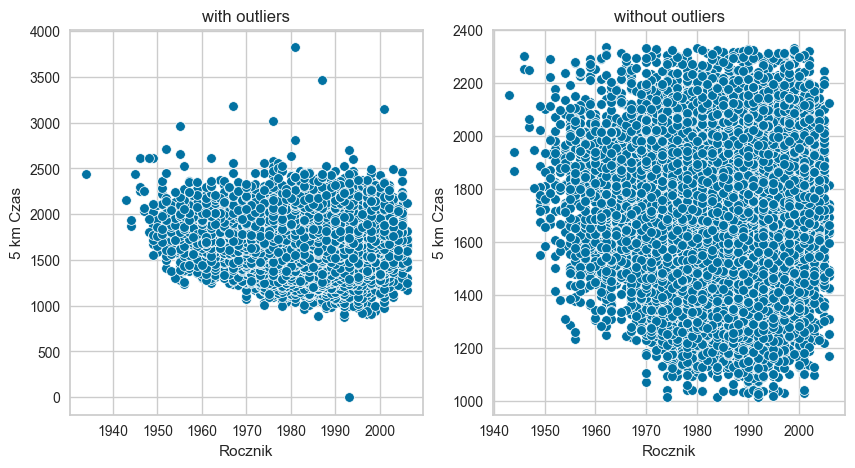

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(data=df, x="Rocznik", y="5 km Czas", ax=axes[0])
axes[0].set_title("with outliers")

sns.scatterplot(data=Distance_5km_no_outliers_df, x="Rocznik", y="5 km Czas", ax=axes[1])
axes[1].set_title("without outliers")


In [34]:
Col = "Czas"
Q1 = df[Col].quantile(0.25)
Q3 = df[Col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Distance_21km_no_outliers_df = df[~((df[Col] < lower_bound) | (df[Col] > upper_bound))]

Text(0.5, 1.0, 'without outliers')

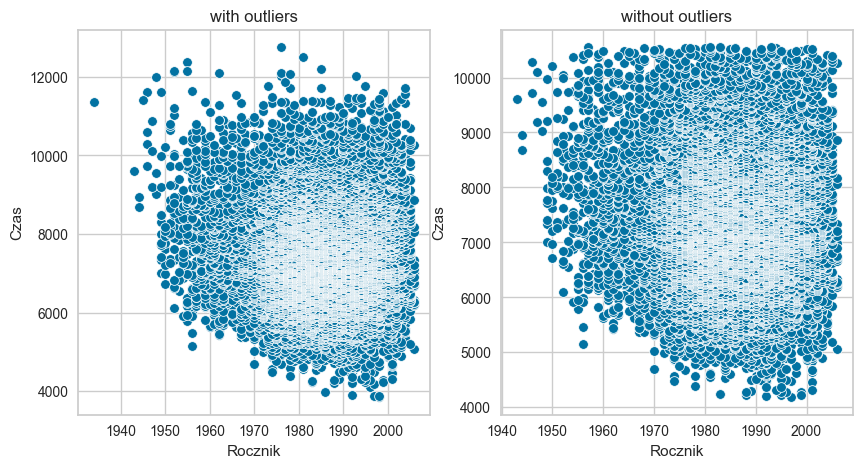

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(data=df, x="Rocznik", y="Czas", ax=axes[0])
axes[0].set_title("with outliers")

sns.scatterplot(data=Distance_21km_no_outliers_df, x="Rocznik", y="Czas", ax=axes[1])
axes[1].set_title("without outliers")


In [70]:
df[df["Rocznik"].isna()]

Empty DataFrame
Columns: [Miejsce, Numer startowy, Imię, Nazwisko, Miasto, Kraj, Drużyna, Płeć, Płeć Miejsce, Kategoria wiekowa, Kategoria wiekowa Miejsce, Rocznik, 5 km Czas, 5 km Miejsce Open, 5 km Tempo, 10 km Czas, 10 km Miejsce Open, 10 km Tempo, 15 km Czas, 15 km Miejsce Open, 15 km Tempo, 20 km Czas, 20 km Miejsce Open, 20 km Tempo, Tempo Stabilność, Czas, Tempo, rok zawodów, Sugerowana kategoria wiekowa]
Index: []

[0 rows x 29 columns]

In [71]:
df.isna().sum()

Miejsce                          0
Numer startowy                   0
Imię                             0
Nazwisko                         0
Miasto                           0
Kraj                             0
Drużyna                          0
Płeć                             0
Płeć Miejsce                     0
Kategoria wiekowa                0
Kategoria wiekowa Miejsce       18
Rocznik                          0
5 km Czas                       36
5 km Miejsce Open               36
5 km Tempo                      36
10 km Czas                      20
10 km Miejsce Open              20
10 km Tempo                     52
15 km Czas                      19
15 km Miejsce Open              19
15 km Tempo                     34
20 km Czas                       8
20 km Miejsce Open               8
20 km Tempo                     25
Tempo Stabilność                70
Czas                             0
Tempo                            0
rok zawodów                      0
Sugerowana kategoria wiekowa     0
dtype: int64

In [72]:
df[df['Rocznik'] < 1940]

Miejsce  Numer startowy       Imię Nazwisko   Miasto Kraj   Drużyna  \
8136     8137            2797  Alexander     King  WROCŁAW  POL  TEAM_319   

     Płeć  Płeć Miejsce Kategoria wiekowa  ...  15 km Miejsce Open  \
8136    M          5823               M80  ...                8137   

      15 km Tempo  20 km Czas  20 km Miejsce Open  20 km Tempo  \
8136     9.013333     10810.0                8135    10.123333   

      Tempo Stabilność     Czas     Tempo  rok zawodów  \
8136          0.124533  11370.0  8.983171         2023   

      Sugerowana kategoria wiekowa  
8136                           M80  

[1 rows x 29 columns]

In [66]:
Ignores_col = ['rok zawodów', '5 km Tempo', '5 km Miejsce Open']
drop_col = ['Tempo', 'Tempo Stabilność', 'Miejsce', 'Numer startowy', 'Nazwisko', 'Miasto', 'Kraj', 'Drużyna', 'Płeć Miejsce','Sugerowana kategoria wiekowa', '10 km Czas', '10 km Miejsce Open', '10 km Tempo', '15 km Czas', '15 km Miejsce Open', '15 km Tempo', '20 km Czas', '20 km Miejsce Open', '20 km Tempo', 'Kategoria wiekowa Miejsce']

In [ ]:
df = df.drop(columns=drop_col, errors='ignore')

In [83]:
df_ignore = df.drop(columns=Ignores_col, errors='ignore')

df_ignore.keys()

Index(['Imię', 'Płeć', 'Kategoria wiekowa', 'Rocznik', '5 km Czas', 'Czas'], dtype='object')

In [88]:
print(df.keys())
print(Distance_5km_no_outliers_df.keys())

Index(['Imię', 'Płeć', 'Kategoria wiekowa', 'Rocznik', '5 km Czas', 'Czas'], dtype='object')
Index(['Imię', 'Płeć', 'Kategoria wiekowa', 'Rocznik', '5 km Czas', 'Czas'], dtype='object')


## Traning

In [32]:
outliers_exp = setup(
    data=df,
    target='Czas',
    session_id=123,
    ignore_features= ['Tempo', 'Miejsce'],# [Ignores_col, ['Tempo', 'Miejsce']],
    # normalize=True,
    # normalize_method='zscore',
    )
outliers_best_model = outliers_exp.compare_models()
outliers_metrics_df = pull()

Description,Value
Session id,123
Target,Czas
Target type,Regression
Original data shape,"(18447, 19)"
Transformed data shape,"(18447, 18)"
Transformed train set shape,"(12912, 18)"
Transformed test set shape,"(5535, 18)"
Ignore features,2
Numeric features,15
Categorical features,2


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
llar,Lasso Least Angle Regression,20.8243,6766.9997,69.1648,0.9953,0.0084,0.0027,0.0440
lr,Linear Regression,20.9015,6893.7134,69.9147,0.9952,0.0086,0.0027,2.0160
lasso,Lasso Regression,21.7024,6874.6830,70.3197,0.9952,0.0084,0.0028,0.0760
ridge,Ridge Regression,20.8684,6886.8020,69.8309,0.9952,0.0085,0.0027,0.0420
br,Bayesian Ridge,20.8407,6871.4153,69.6388,0.9952,0.0085,0.0027,0.0670
en,Elastic Net,27.8423,7210.9754,73.3475,0.9950,0.0090,0.0037,0.0840
lightgbm,Light Gradient Boosting Machine,24.6232,7381.8788,75.8383,0.9949,0.0094,0.0032,0.1680
gbr,Gradient Boosting Regressor,25.5949,7496.2933,75.1276,0.9948,0.0092,0.0034,1.3620
et,Extra Trees Regressor,20.3667,7501.4369,74.4652,0.9948,0.0091,0.0026,1.3730
huber,Huber Regressor,29.3488,7623.4446,76.6715,0.9947,0.0094,0.0039,0.1410


In [72]:
outliers_exp = setup(
    data=df,
    target='Czas',
    session_id=123,
    ignore_features= Ignores_col,
    # normalize=True,
    # normalize_method='zscore',
    )
outliers_best_model = outliers_exp.compare_models()
outliers_metrics_df = pull()

Description,Value
Session id,123
Target,Czas
Target type,Regression
Original data shape,"(18447, 9)"
Transformed data shape,"(18447, 18)"
Transformed train set shape,"(12912, 18)"
Transformed test set shape,"(5535, 18)"
Ignore features,3
Numeric features,2
Categorical features,3


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,304.2788,179535.5690,423.3424,0.8785,0.0536,0.0397,0.2730
lightgbm,Light Gradient Boosting Machine,308.8359,185062.1962,429.8043,0.8748,0.0543,0.0403,0.1210
catboost,CatBoost Regressor,309.5752,186748.5543,431.7554,0.8736,0.0545,0.0403,1.1730
llar,Lasso Least Angle Regression,306.9602,190268.0072,435.4325,0.8709,0.0585,0.0400,0.0390
lasso,Lasso Regression,306.9604,190268.1185,435.4326,0.8709,0.0585,0.0400,0.0500
en,Elastic Net,306.8110,190183.2944,435.3331,0.8709,0.0584,0.0400,0.0450
omp,Orthogonal Matching Pursuit,307.1291,190379.5535,435.5692,0.8708,0.0584,0.0400,0.0350
br,Bayesian Ridge,306.9002,190338.0303,435.5083,0.8708,0.0584,0.0400,0.0370
lr,Linear Regression,307.4410,190663.0195,435.8824,0.8706,0.0586,0.0401,0.0490
ridge,Ridge Regression,307.4199,190648.0340,435.8648,0.8706,0.0586,0.0401,0.0460


In [97]:
Distance_5km_no_outliers_df.keys()

Index(['Imię', 'Płeć', 'Kategoria wiekowa', 'Rocznik', '5 km Czas', 'Czas'], dtype='object')

In [89]:
without_outliers_5km_exp = setup(
    data=Distance_5km_no_outliers_df, 
    target='Czas', 
    session_id=123, 
    ignore_features= Ignores_col,
    # normalize=True,
    # normalize_method='zscore'
    )
without_outliers_5km_best_model = without_outliers_5km_exp.compare_models()
without_outliers_5km_metrics_df = pull()

Description,Value
Session id,123
Target,Czas
Target type,Regression
Original data shape,"(18308, 6)"
Transformed data shape,"(18308, 18)"
Transformed train set shape,"(12815, 18)"
Transformed test set shape,"(5493, 18)"
Ignore features,3
Numeric features,2
Categorical features,3


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,301.7333,175719.1708,418.6857,0.8744,0.0531,0.0395,0.2920
en,Elastic Net,302.8212,176278.0969,419.3401,0.8740,0.0533,0.0396,0.0520
br,Bayesian Ridge,302.8229,176274.0712,419.3347,0.8740,0.0533,0.0396,0.0530
lasso,Lasso Regression,302.9295,176395.0805,419.4825,0.8739,0.0533,0.0396,0.0530
llar,Lasso Least Angle Regression,302.9295,176395.0885,419.4825,0.8739,0.0533,0.0396,0.0440
omp,Orthogonal Matching Pursuit,303.0776,176416.4671,419.5175,0.8739,0.0533,0.0396,0.0500
lr,Linear Regression,303.3427,176715.5599,419.8719,0.8737,0.0533,0.0397,0.7610
ridge,Ridge Regression,303.3137,176685.3488,419.8359,0.8737,0.0533,0.0397,0.0470
huber,Huber Regressor,298.8828,179268.8951,422.8515,0.8719,0.0535,0.0388,0.0750
lightgbm,Light Gradient Boosting Machine,305.2958,180534.3806,424.4042,0.8710,0.0538,0.0399,0.1410


In [73]:
# Compare models
outliers_metrics_df = outliers_metrics_df.sort_index()
no_outliers_metrics_df = without_outliers_5km_metrics_df.sort_index()

compare_metrics_df = outliers_metrics_df.compare(no_outliers_metrics_df)
compare_metrics_df.rename(columns={"self": "O", "other": "NO_O"}, inplace=True)

compare_metrics_df = compare_metrics_df[[
    ('MAE',  'O'),
    ('MAE', 'NO_O'),
    ('MSE',  'O'),
    ('MSE', 'NO_O'),
    ('RMSE',  'O'),
    ('RMSE', 'NO_O'),
    ('R2',  'O'),
    ('R2', 'NO_O'),
]]
compare_metrics_df.drop('dummy', inplace=True)
compare_metrics_df = compare_metrics_df.sort_values(by=[('MAE', 'O')], ascending=False)
compare_metrics_df

MAE                         MSE                     RMSE  \
                  O          NO_O             O          NO_O          O   
lar       4354.8059  2.061877e+06  6.200132e+08  6.069291e+13  8775.6506   
ada        486.8135  4.837904e+02  3.550102e+05  3.537016e+05   594.1730   
dt         432.8756  4.312881e+02  3.625999e+05  3.567419e+05   601.9625   
par        408.3406  3.937475e+02  2.922719e+05  2.541919e+05   534.9767   
et         346.8964  3.460797e+02  2.313444e+05  2.271809e+05   480.7198   
knn        334.6536  3.322913e+02  2.134403e+05  2.093592e+05   461.7226   
rf         329.6502  3.285366e+02  2.070291e+05  2.049573e+05   454.6983   
xgboost    321.4765  3.187536e+02  2.027494e+05  1.969753e+05   449.9131   
catboost   309.5752  3.061738e+02  1.867486e+05  1.824647e+05   431.7554   
lightgbm   308.8359  3.052958e+02  1.850622e+05  1.805344e+05   429.8043   
lr         307.4410  3.033427e+02  1.906630e+05  1.767156e+05   435.8824   
ridge      307.4199  3.033137e+02  1.906480e+05  1.766853e+05   435.8648   
omp        307.1291  3.030776e+02  1.903796e+05  1.764165e+05   435.5692   
lasso      306.9604  3.029295e+02  1.902681e+05  1.763951e+05   435.4326   
llar       306.9602  3.029295e+02  1.902680e+05  1.763951e+05   435.4325   
br         306.9002  3.028229e+02  1.903380e+05  1.762741e+05   435.5083   
en         306.8110  3.028212e+02  1.901833e+05  1.762781e+05   435.3331   
gbr        304.2788  3.017333e+02  1.795356e+05  1.757192e+05   423.3424   
huber      302.2601  2.988828e+02  1.927455e+05  1.792689e+05   438.2962   

                              R2                
                  NO_O         O          NO_O  
lar       2.464222e+06 -460.7060 -4.107155e+07  
ada       5.939359e+02    0.7590  7.470000e-01  
dt        5.970621e+02    0.7545  7.448000e-01  
par       4.978529e+02    0.8007  8.185000e-01  
et        4.762278e+02    0.8434  8.376000e-01  
knn       4.571576e+02    0.8556  8.503000e-01  
rf        4.522415e+02    0.8599  8.535000e-01  
xgboost   4.432976e+02    0.8628  8.592000e-01  
catboost  4.266501e+02    0.8736  8.696000e-01  
lightgbm  4.244042e+02    0.8748  8.710000e-01  
lr        4.198719e+02    0.8706  8.737000e-01  
ridge     4.198359e+02    0.8706  8.737000e-01  
omp       4.195175e+02    0.8708  8.739000e-01  
lasso     4.194825e+02    0.8709  8.739000e-01  
llar      4.194825e+02    0.8709  8.739000e-01  
br        4.193347e+02    0.8708  8.740000e-01  
en        4.193401e+02    0.8709  8.740000e-01  
gbr       4.186857e+02    0.8785  8.744000e-01  
huber     4.228515e+02    0.8692  8.719000e-01

In [135]:
print(outliers_metrics_df.index)
print(no_outliers_metrics_df.index)

Index(['ada', 'br', 'catboost', 'dt', 'dummy', 'en', 'et', 'gbr', 'huber',
       'knn', 'lar', 'lasso', 'lightgbm', 'llar', 'lr', 'omp', 'par', 'rf',
       'ridge', 'xgboost'],
      dtype='object')
Index(['ada', 'br', 'catboost', 'dt', 'dummy', 'en', 'et', 'gbr', 'huber',
       'knn', 'lar', 'lasso', 'lightgbm', 'llar', 'lr', 'omp', 'par', 'rf',
       'ridge', 'xgboost'],
      dtype='object')


In [74]:
def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: #8B8000' if v else '' for v in is_min]

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #8B8000' if v else '' for v in is_max]

metric_names = ['MAE', 'MSE', 'RMSE', 'R2']
styler_of_df = compare_metrics_df.style
styler_of_df = styler_of_df.set_table_styles({
    (metric_name, 'NO_O'): [{'selector': '', 'props': 'border-right: 4px solid white;'}]
    for metric_name in metric_names
})
for metric_name in ['MAE', 'MSE', 'RMSE']:
    styler_of_df = styler_of_df.apply(highlight_min, subset=[(metric_name, 'O'), (metric_name, 'NO_O')], axis=1)

styler_of_df = styler_of_df.apply(highlight_max, subset=[('R2', 'O'), ('R2', 'NO_O')], axis=1)
styler_of_df

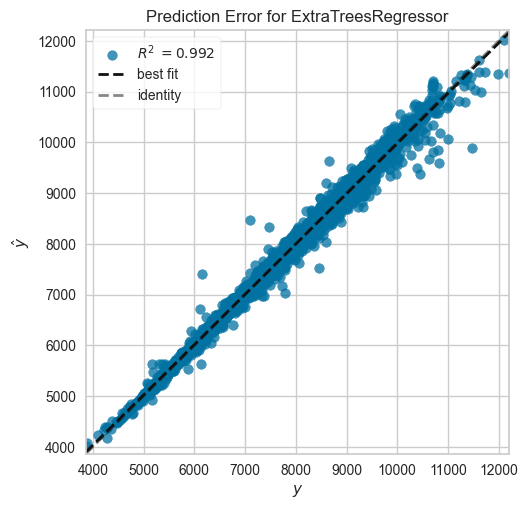

In [81]:
outliers_exp.plot_model(outliers_best_model, plot='error')

In [82]:
# Compare models
outliers_metrics_df = outliers_metrics_df.sort_index()
no_outliers_5km_metrics_df = without_outliers_5km_metrics_df.sort_index()

compare_metrics_df = outliers_metrics_df.compare(no_outliers_5km_metrics_df)
compare_metrics_df.rename(columns={"self": "O", "other": "NO_O"}, inplace=True)

compare_metrics_df = compare_metrics_df[[
    ('MAE',  'O'),
    ('MAE', 'NO_O'),
    ('MSE',  'O'),
    ('MSE', 'NO_O'),
    ('RMSE',  'O'),
    ('RMSE', 'NO_O'),
    ('R2',  'O'),
    ('R2', 'NO_O'),
]]
compare_metrics_df.drop('dummy', inplace=True)
compare_metrics_df = compare_metrics_df.sort_values(by=[('MAE', 'O')], ascending=False)
compare_metrics_df

MAE                         MSE                      RMSE  \
                   O          NO_O             O          NO_O           O   
lar       25312.3697  7.512111e+11  8.656743e+08  5.061249e+24  29324.6256   
omp         864.4752  2.679729e+02  1.145122e+06  1.357192e+05   1069.4904   
par         452.7132  3.112535e+02  3.612186e+05  1.680490e+05    561.0690   
ada         437.0352  3.256725e+02  2.906676e+05  1.466081e+05    537.1803   
en          292.0946  2.611400e+02  1.734337e+05  1.309320e+05    415.7901   
huber       289.8848  2.636437e+02  1.783562e+05  1.441517e+05    421.6497   
knn         207.7052  1.498838e+02  1.158560e+05  7.387106e+04    340.0883   
dt          101.2557  7.144710e+01  3.610346e+04  2.514449e+04    188.1512   
gbr          83.6591  7.737550e+01  2.416080e+04  1.770531e+04    152.5205   
lasso        82.6510  8.530110e+01  3.017019e+04  2.361209e+04    167.7529   
llar         82.6510  8.530110e+01  3.017019e+04  2.361209e+04    167.7529   
ridge        81.4540  8.375140e+01  2.978825e+04  2.315031e+04    166.6238   
lr           79.6859  8.013960e+01  2.950673e+04  2.275131e+04    165.8200   
br           79.6756  8.014630e+01  2.949813e+04  2.275014e+04    165.7954   
xgboost      77.7983  5.445850e+01  2.061557e+04  1.004199e+04    142.2455   
lightgbm     77.7562  5.825500e+01  2.133144e+04  1.147930e+04    143.0935   
rf           75.2188  5.107200e+01  2.315285e+04  1.443290e+04    149.5193   
catboost     72.2773  5.327990e+01  1.872270e+04  8.947576e+03    134.3166   
et           61.8665  4.047240e+01  1.630789e+04  1.008746e+04    125.3314   

                              R2                
                  NO_O         O          NO_O  
lar       8.665102e+11 -582.3683 -3.528339e+18  
omp       3.681148e+02    0.2275  9.030000e-01  
par       4.086012e+02    0.7541  8.794000e-01  
ada       3.825867e+02    0.8032  8.949000e-01  
en        3.615269e+02    0.8824  9.064000e-01  
huber     3.793130e+02    0.8791  8.970000e-01  
knn       2.710237e+02    0.9216  9.472000e-01  
dt        1.565404e+02    0.9754  9.820000e-01  
gbr       1.304226e+02    0.9836  9.874000e-01  
lasso     1.508051e+02    0.9792  9.831000e-01  
llar      1.508051e+02    0.9792  9.831000e-01  
ridge     1.492194e+02    0.9795  9.835000e-01  
lr        1.476488e+02    0.9797  9.838000e-01  
br        1.476461e+02    0.9797  9.838000e-01  
xgboost   9.868430e+01    0.9860  9.929000e-01  
lightgbm  1.040353e+02    0.9855  9.919000e-01  
rf        1.156781e+02    0.9842  9.898000e-01  
catboost  9.237030e+01    0.9873  9.937000e-01  
et        9.665350e+01    0.9889  9.929000e-01

In [83]:
def highlight_min(s):
    is_min = s == s.min()
    return ['background-color: #8B8000' if v else '' for v in is_min]

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #8B8000' if v else '' for v in is_max]

metric_names = ['MAE', 'MSE', 'RMSE', 'R2']
styler_of_df = compare_metrics_df.style
styler_of_df = styler_of_df.set_table_styles({
    (metric_name, 'NO_O'): [{'selector': '', 'props': 'border-right: 4px solid white;'}]
    for metric_name in metric_names
})
for metric_name in ['MAE', 'MSE', 'RMSE']:
    styler_of_df = styler_of_df.apply(highlight_min, subset=[(metric_name, 'O'), (metric_name, 'NO_O')], axis=1)

styler_of_df = styler_of_df.apply(highlight_max, subset=[('R2', 'O'), ('R2', 'NO_O')], axis=1)
styler_of_df

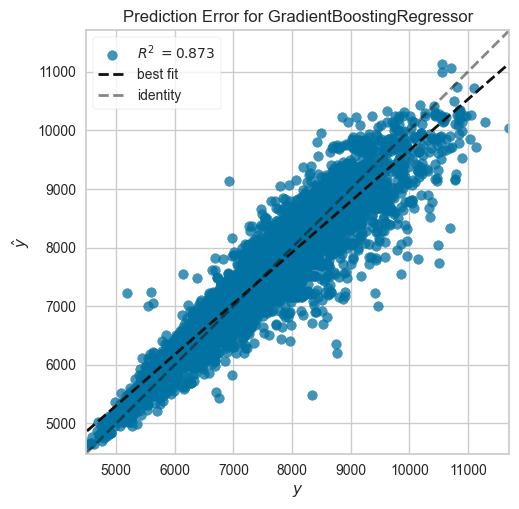

In [90]:
without_outliers_5km_exp.plot_model(without_outliers_5km_best_model, plot='error')

In [142]:
outliers_exp.dataset_transformed

Numer startowy         Imię     Nazwisko       Miasto         Kraj  \
4237          8552.0  7947.469727  7542.207438  7490.512207  7348.922363   
6326          1700.0  7318.633390  7301.150279  7490.512207  7348.922363   
6601          1649.0  7045.488278  7084.839928  7426.417936  7348.922363   
1767          4052.0  7104.633549  7344.483845  7255.279308  7348.922363   
2253          5786.0  7143.614621  7437.655786  7490.512207  7348.922363   
...              ...          ...          ...          ...          ...   
4458          3051.0  7947.469727  7342.462891  7490.512207  7348.922363   
4139          4718.0  7461.861107  7395.341338  7339.824490  7348.922363   
7512           148.0  7196.211699  7065.534585  7378.356474  7348.922363   
4212          6891.0  7321.040121  7399.891519  7490.512207  7348.922363   
5003          2224.0  7342.462891  7194.393698  7127.371707  7348.922363   

          Drużyna  Płeć  Płeć Miejsce  Kategoria wiekowa_K30  \
4237  7468.306152   0.0         692.0                    1.0   
6326  7468.306152   1.0        4894.0                    0.0   
6601  7468.306152   1.0        5039.0                    0.0   
1767  7206.858537   1.0        1615.0                    0.0   
2253  7468.306152   1.0        2032.0                    0.0   
...           ...   ...           ...                    ...   
4458  7266.776548   0.0         759.0                    0.0   
4139  7468.306152   1.0        3470.0                    0.0   
7512  7370.896421   1.0        5507.0                    0.0   
4212  7468.306152   1.0        3530.0                    0.0   
5003  7468.306152   1.0        4077.0                    0.0   

      Kategoria wiekowa_M40  ...  Sugerowana kategoria wiekowa_K20  \
4237                    0.0  ...                               0.0   
6326                    1.0  ...                               0.0   
6601                    1.0  ...                               0.0   
1767                    0.0  ...                               0.0   
2253                    0.0  ...                               0.0   
...                     ...  ...                               ...   
4458                    0.0  ...                               1.0   
4139                    0.0  ...                               0.0   
7512                    0.0  ...                               0.0   
4212                    0.0  ...                               0.0   
5003                    0.0  ...                               0.0   

      Sugerowana kategoria wiekowa_M20  Sugerowana kategoria wiekowa_M50  \
4237                               0.0                               0.0   
6326                               0.0                               0.0   
6601                               0.0                               0.0   
1767                               0.0                               0.0   
2253                               0.0                               0.0   
...                                ...                               ...   
4458                               0.0                               0.0   
4139                               0.0                               0.0   
7512                               1.0                               0.0   
4212                               0.0                               0.0   
5003                               0.0                               0.0   

      Sugerowana kategoria wiekowa_M60  Sugerowana kategoria wiekowa_K50  \
4237                               0.0                               0.0   
6326                               0.0                               0.0   
6601                               0.0                               0.0   
1767                               0.0                               0.0   
2253                               0.0                               0.0   
...                                ...                               ...   
4458                               0.0

In [143]:
transformed_exp = setup(
    data=df,
    target='Czas',
    verbose=False,
    transformation=True,
    transformation_method='yeo-johnson',
    session_id=123,
)
best_transformed_model = transformed_exp.compare_models()


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,5.6494,599.0198,19.8963,0.7996,0.0027,0.0008,0.5570
catboost,CatBoost Regressor,14.6551,1750.1867,35.2455,0.7988,0.0046,0.0020,3.3440
ridge,Ridge Regression,41.8296,6717.3410,73.2619,0.7954,0.0122,0.0058,0.1210
lasso,Lasso Regression,53.9265,10347.4686,90.9267,0.7929,0.0137,0.0073,0.1440
en,Elastic Net,120.3777,44317.1672,187.8848,0.7696,0.0215,0.0153,0.1540
lar,Least Angle Regression,761.3767,1154706.2288,960.8370,0.0068,0.1299,0.1059,0.1340
dummy,Dummy Regressor,764.4475,1167231.3500,966.1653,-0.0012,0.1310,0.1066,0.3690
llar,Lasso Least Angle Regression,765.6435,1172670.6587,968.4410,-0.0050,0.1313,0.1068,0.1160
lr,Linear Regression,765.9509,1173311.5113,968.6851,-0.0054,0.1313,0.1068,0.9210
omp,Orthogonal Matching Pursuit,766.3110,1174020.1745,968.9786,-0.0059,0.1313,0.1069,0.1350


NameError: name 'transformed_exp' is not defined

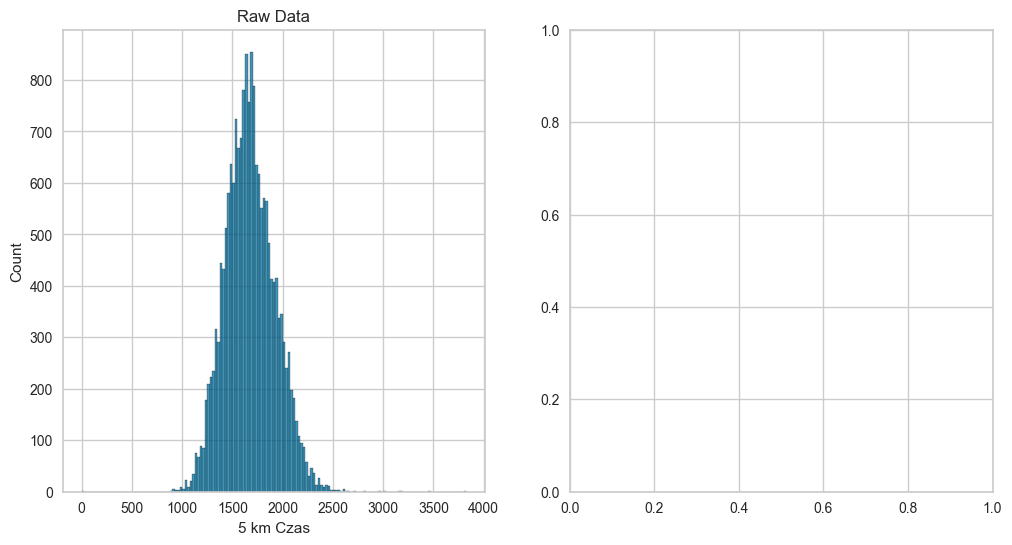

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(outliers_exp.dataset_transformed, x="5 km Czas", ax=axes[0])
axes[0].set_title("Raw Data")
sns.histplot(transformed_exp.dataset_transformed, x="5 km Czas", ax=axes[1])
axes[1].set_title("Transformed Data")

Text(0.5, 1.0, 'Transformed Data')

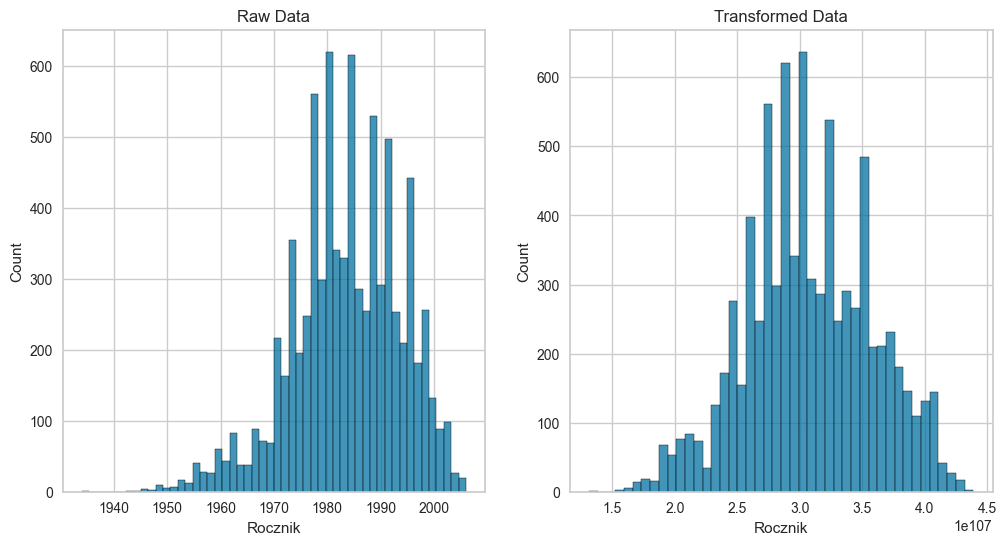

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(outliers_exp.dataset_transformed, x="Rocznik", ax=axes[0])
axes[0].set_title("Raw Data")
sns.histplot(transformed_exp.dataset_transformed, x="Rocznik", ax=axes[1])
axes[1].set_title("Transformed Data")

In [118]:
df['Aktywność fizyczna'] = pd.cut(df['Czas'], bins=5, labels=[' bardzo duża', 'duża', 'umiarkowana', 'mała', 'brak'])
df['Aktywność fizyczna'].value_counts()

Aktywność fizyczna
duża            3876
umiarkowana     2922
mała             825
 bardzo duża     464
brak              62
Name: count, dtype: int64

In [101]:
df = df.drop(columns='Sugerowana kategoria wiekowa')

KeyError: "['Sugerowana kategoria wiekowa'] not found in axis"

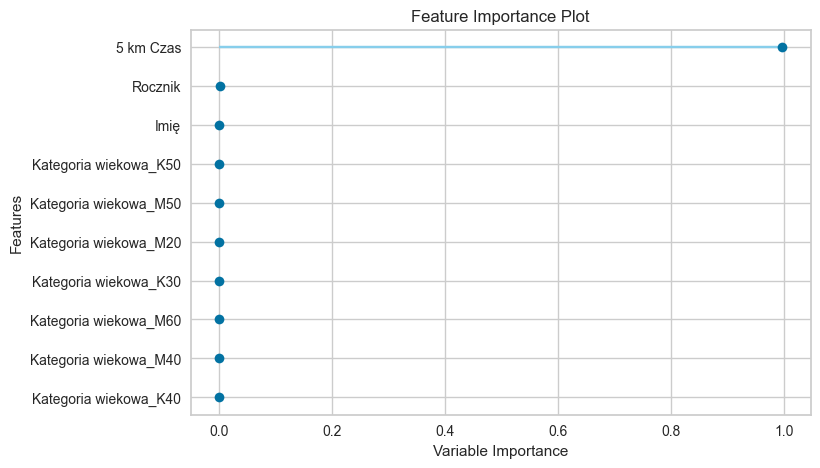

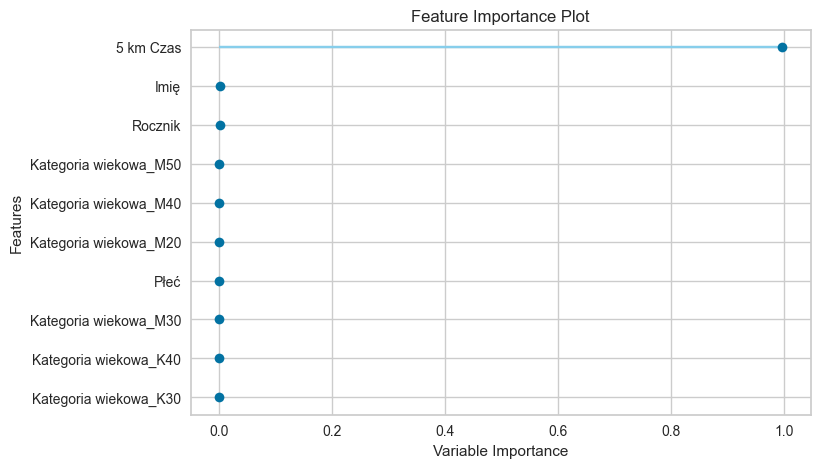

In [91]:
outliers_exp.plot_model(outliers_best_model, plot="feature")
without_outliers_5km_exp.plot_model(without_outliers_5km_best_model, plot="feature")

In [92]:
best_tuned_model = without_outliers_5km_exp.tune_model(
    without_outliers_5km_best_model,
    optimize="R2",
    choose_better=True,
)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,321.3588,187083.8694,432.5319,0.8647,0.0551,0.0422
1,307.5656,197233.0605,444.1093,0.8514,0.0572,0.0408
2,324.1109,197909.0568,444.8697,0.8531,0.0560,0.0424
3,317.0992,188293.9322,433.9285,0.8546,0.0552,0.0419
4,335.9225,224946.3567,474.2851,0.8478,0.0594,0.0434
5,321.6316,188182.3748,433.7999,0.8687,0.0553,0.0423
6,329.7225,198324.3759,445.3363,0.8644,0.0560,0.0429
7,317.5776,197922.0022,444.8843,0.8572,0.0568,0.0414
8,333.5804,226091.6602,475.4910,0.8391,0.0592,0.0432


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [93]:
without_outliers_5km_exp.predict_model(best_tuned_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,305.0206,177563.6924,421.3831,0.8727,0.0536,0.0399


Imię Płeć Kategoria wiekowa  Rocznik  5 km Czas    Czas  \
16336     Jonathan    M               M30     1990     1958.0  8415.0   
1662         Larry    M               M20     1999     1495.0  6348.0   
10643  Christopher    M               M30     1986     1544.0  6577.0   
9835        Robert    M               M20     1997     1490.0  6296.0   
3247       William    M               M30     1992     1574.0  6948.0   
...            ...  ...               ...      ...        ...     ...   
15797      Timothy    M               M60     1961     1970.0  8176.0   
7519         Jesus    M               M50     1970     2082.0  9222.0   
17953         Paul    M               M40     1983     2127.0  9687.0   
7348       Anthony    M               M40     1976     2005.0  9045.0   
11660       Daniel    M               M20     2000     1693.0  6904.0   

       prediction_label  
16336       8671.262236  
1662        6598.267299  
10643       6793.976073  
9835        6539.859629  
3247        6910.223603  
...                 ...  
15797       8790.561828  
7519        9417.943565  
17953       9643.628817  
7348        9034.318821  
11660       7432.517311  

[5493 rows x 7 columns]

In [94]:
best_final_model = without_outliers_5km_exp.finalize_model(best_tuned_model)
best_final_model

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['Rocznik', '5 km Czas'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['Imię', 'Płeć',
                                             'Kategoria wiekowa'],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('ordinal_encoding',
                 TransformerWrapper(include=['Płeć'],
                                    transforme...
                                    transformer=OneHotEncoder(cols=['Kategoria '
                                                                    'wiekowa'],
                                                              handle_missing='return_nan',
                                                              use_cat_names=True))),
                ('rest_encoding',
                 TransformerWrapper(include=['Imię'],
                                    transformer=TargetEncoder(cols=['Imię'],
                                                              handle_missing='return_nan'))),
                ('clean_column_names',
                 TransformerWrapper(transformer=CleanColumnNames())),
                ('actual_estimator',
                 GradientBoostingRegressor(random_state=123))])

###  Zapisanie modelu lokalnie

In [95]:
os.makedirs(MOD_FILE, exist_ok=True)
local_file_path = os.path.join(MOD_FILE, "best_5km_model_2023_2024")
without_outliers_5km_exp.save_model(best_final_model, local_file_path, verbose=False);

###  Zapisanie modelu do Digital Ocean

In [96]:
# Zapis Digital Ocean
local_file_path2 = local_file_path + ".pkl"
s3_path = local_file_path2.replace("\\","/").replace(MOD_FILE, S3_MOD_FILE)
print(f"Wysyłam plik {local_file_path} do {s3_path}") 
s3.upload_file(
    Filename=local_file_path2,
    Bucket=BUCKET_NAME,
    Key=s3_path
)


Wysyłam plik Models\best_5km_model_2023_2024 do Models/best_5km_model_2023_2024.pkl


In [92]:
from pycaret.regression import load_model, predict_model
import pandas as pd

# 1. Wczytaj model zapisany wcześniej
model = load_model('Models/best_5km_model')

# 2. Wczytaj nowe dane, na których chcesz zrobić predykcję
nowe_dane = pd.read_csv('sourceFile\halfmarathon_wroclaw_2024__final.csv', sep=";")

nowe_dane = nowe_dane.dropna(subset=['Czas'], how='all')
# 3. Zrób predykcję
# wynik = predict_model(model, data=nowe_dane)

# print(wynik.head())

Transformation Pipeline and Model Successfully Loaded


In [125]:
print(df.keys())
print(nowe_dane.keys())


Index(['Imię', 'Płeć', 'Kategoria wiekowa Miejsce', 'Rocznik', '5 km Czas',
       '5 km Miejsce Open', '5 km Tempo', '10 km Czas', '10 km Miejsce Open',
       '10 km Tempo', '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
       '20 km Czas', '20 km Miejsce Open', '20 km Tempo', 'Tempo Stabilność',
       'Czas', 'Tempo'],
      dtype='object')
Index(['Miejsce', 'Numer startowy', 'Imię', 'Nazwisko', 'Miasto', 'Kraj',
       'Drużyna', 'Płeć', 'Płeć Miejsce', 'Kategoria wiekowa',
       'Kategoria wiekowa Miejsce', 'Rocznik', '5 km Czas',
       '5 km Miejsce Open', '5 km Tempo', '10 km Czas', '10 km Miejsce Open',
       '10 km Tempo', '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
       '20 km Czas', '20 km Miejsce Open', '20 km Tempo', 'Tempo Stabilność',
       'Czas', 'Tempo'],
      dtype='object')


## Funkcja do czyszczenia danych

In [13]:
def Convert_DF(df, rocznik: int):
    time_cols = ["Czas","5 km Czas", "10 km Czas", "15 km Czas", "20 km Czas"]
    for col in time_cols:
        df[col] = df[col].apply(convert_time_to_seconds)
    int64_col = ["Miejsce","Płeć Miejsce", "Kategoria wiekowa Miejsce", "Rocznik", "5 km Miejsce Open", "10 km Miejsce Open", "15 km Miejsce Open", "20 km Miejsce Open"]
    df[int64_col]=df[int64_col].astype("Int64")
    df["Imię"] = df["Płeć"].apply(create_name)
    df["Nazwisko"] = df["Nazwisko"].apply(lambda x: fake.last_name())
    team_mapping = {team: f"TEAM_{i:03d}" for i, team in enumerate(df["Drużyna"].unique())}
    # TEAM_001, TEAM_002, TEAM_003...
    team_mapping_reverse = {v: k for k, v in team_mapping.items()}
    df["Drużyna"] = df["Drużyna"].map(team_mapping)
    df = df.dropna(subset=['Płeć'])
    df = df.dropna(subset=['5 km Czas', '10 km Czas', '15 km Czas', '20 km Czas'], how='all')
    fill_mapping = ['Miasto', 'Drużyna']
    df[fill_mapping] = df[fill_mapping].fillna('No Data')
    # fillRocznik(df, 1260)
    df['Kategoria wiekowa'] = df.apply(fill_KategoriaWiekowa, axis=1, args=(rocznik,))
    df = df.dropna(subset=['Kategoria wiekowa'], how='all')
    schema.validate(df)
    

In [94]:
nowe_dane.keys()

Index(['Miejsce', 'Numer startowy', 'Imię', 'Nazwisko', 'Miasto', 'Kraj',
       'Drużyna', 'Płeć', 'Płeć Miejsce', 'Kategoria wiekowa',
       'Kategoria wiekowa Miejsce', 'Rocznik', '5 km Czas',
       '5 km Miejsce Open', '5 km Tempo', '10 km Czas', '10 km Miejsce Open',
       '10 km Tempo', '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
       '20 km Czas', '20 km Miejsce Open', '20 km Tempo', 'Tempo Stabilność',
       'Czas', 'Tempo'],
      dtype='object')

In [ ]:
Convert_DF(nowe_dane, 2024)
nowe_dane = nowe_dane.dropna(subset=['Czas'])

In [65]:
Convert_DF(df, 2024)

In [96]:
wynik = predict_model(model, data=nowe_dane)
print(wynik.head())

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,116.8396,40478.4054,201.1925,0.9726,0.0234,0.0148


   Miejsce  Numer startowy         Imię  Nazwisko   Miasto Kraj   Drużyna  \
0        1             596        Jason   Mullins  KOŚCIAN  POL  TEAM_000   
1        2             616         Ryan     Brown    RADOM  POL  TEAM_001   
2        3             154  Christopher       Ray    RADOM  POL  TEAM_002   
3        4             591     Benjamin     Jones  WROCŁAW  POL  TEAM_003   
4        5             521       Steven  Franklin    LUBON  POL  TEAM_004   

  Płeć  Płeć Miejsce Kategoria wiekowa  ...  15 km Czas  15 km Miejsce Open  \
0    M             1               M20  ...      2707.0                   2   
1    M             2               M20  ...      2707.0                   3   
2    M             3               M20  ...      2707.0                   1   
3    M             4               M20  ...      2868.0                   4   
4    M             5               M30  ...      2889.0                   5   

   15 km Tempo  20 km Czas  20 km Miejsce Open  20 km Tempo  T

In [2]:
import json
import streamlit as st
import pandas as pd
from dotenv import load_dotenv
import os
from pycaret.regression import load_model, predict_model
import openai
import datetime


load_dotenv()


# Constants
MODEL_NAME = "best_5km_model_2023_2024" #.pkl"
MODEL_FOLDER = "Models"

model_path = os.path.join(MODEL_FOLDER, MODEL_NAME) # f"{MODEL_NAME}.pkl")

print(model_path)

Models\best_5km_model_2023_2024


In [99]:
model = load_model("Models/best_5km_model_2023_2024")
print(model.feature_names_in_)

Transformation Pipeline and Model Successfully Loaded
['Imię', 'Płeć', 'Kategoria wiekowa', 'Rocznik', '5 km Czas', 'Czas']


In [ ]:
from do_bucked import load_model

load_model("best_5km_model_2023_2024")

SyntaxError: invalid syntax (870273193.py, line 1)